<h1 style="color:violet; font-weight:bold; text-align:center;">Middleware</h1>
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following

* Tracking agent behavior with logging, analytics, and debugging.
* Transforming prompts, tool selection, and output formatting.
* Adding retries, fallbacks, and early termination logic.
* Applying rate limits, gaurdrails, and PII detection

In [32]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
openAI = init_chat_model('gpt-5.1')
# openAI.invoke('what are the chat models offered by openAI')
openAI.profile

{'name': 'GPT-5.1',
 'release_date': '2025-11-13',
 'last_updated': '2025-11-13',
 'open_weights': False,
 'max_input_tokens': 272000,
 'max_output_tokens': 128000,
 'text_inputs': True,
 'image_inputs': True,
 'audio_inputs': False,
 'video_inputs': False,
 'text_outputs': True,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': True,
 'tool_calling': True,
 'structured_output': True,
 'attachment': True,
 'temperature': False,
 'image_url_inputs': True,
 'pdf_inputs': True,
 'pdf_tool_message': True,
 'image_tool_message': True,
 'tool_choice': True}

<h2 style="color:seagreen; font-weight:bold; text-align:center;">Summarization Middleware</h2>

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. SUmmarization is useful for the following:
* Long-running conversations that exceed context windows.
* Multi-turn dialouges with exetnsive history.
* Applications where preserving full conversation context matters.




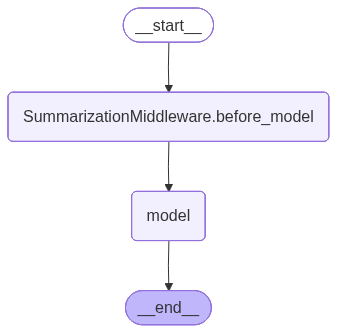

In [33]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# Message based summarization

agent = create_agent(
    model='gpt-4o-mini',
    system_prompt="You are a helpful assistant.",
    middleware=[SummarizationMiddleware(
        model='gpt-4o-mini',
        trigger=('messages',10),
        keep=('messages',5),
        system_prompt="You are a helpful assistant.",
        
    )],
    checkpointer=InMemorySaver()
)

agent

In [34]:
# Run with thread ID
config = {'configurable': {'thread_id': 'test-1'}}

In [35]:
# Alternative test data
questions = [
    'what is langchain',
    'what is langgraph',
    'what is genAI',
    'what is LLM',
    'what is LangChain Expression Language (LCEL)?',
    'What are the key components of LangChain?',
    'How do you create a simple chain in LangChain?',
    'What is the purpose of the LangGraph library?',
    'Can you explain the concept of state in LangGraph?',
    'What are the advantages of using LangChain for building LLM applications?',
    'How does LangChain handle memory in conversations?',
    'What are some common use cases for LangChain?',
    'How do you integrate LangChain with other tools and APIs?',
    'What are the differences between LangChain and LangGraph?',
    'How do you deploy a LangChain application?',
    'What are some best practices for building LLM applications with LangChain?',
    'How do you evaluate and improve the performance of a LangChain application?',
    'What are some common challenges when working with LLMs and how does LangChain help address them?',
    'What are some advanced features of LangChain?',
    'How do you contribute to the LangChain project?'
]

for q in questions:
    response = agent.invoke({'messages': [HumanMessage(content=q)]}, config=config)
    print(f"Question: {q}")
    print(f"Messages: {len(response['messages'])}")
    print(f"Response: {response['messages'][-1].content}")
    print("\n")

Question: what is langchain
Messages: 2
Response: LangChain is a framework designed to facilitate the development of applications powered by large language models (LLMs). It provides a cohesive set of tools and components that make it easier to build AI applications involving natural language processing (NLP) tasks such as chatbots, question-answering systems, and content generation.

Key features of LangChain include:

1. **Integration with Language Models**: LangChain seamlessly integrates with various LLMs, such as OpenAI's GPT models, allowing developers to leverage their capabilities in applications.

2. **Component Modularity**: The framework is modular, meaning developers can use only the components they need, making it flexible for different use cases.

3. **Memory Management**: LangChain includes support for memory, allowing applications to maintain context over conversations or interactions, which is particularly useful for chatbots.

4. **Prompt Management**: The framework p

In [46]:
from langchain_core.tools import tool

@tool
def search_hotel(city:str):
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
        1. Hotel A - 5 Star, $350/night,spa,pool,gym,free-wifi,breakfast-included
        2. Hotel B - 4 Star, $250/night,pool,gym,free-wifi
        3. Hotel C - 3 Star, $150/night,gym,free-wifi
    """ 
agent = create_agent(
    model="gpt-3.5-turbo",
    tools=[search_hotel],
    system_prompt="You are a helpful assistant.",
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(
        model="gpt-3.5-turbo",
        trigger=('tokens',550),
        keep=('tokens',200),
        system_prompt="You are a helpful assistant.",
        checkpointer=InMemorySaver()
    )]
)
config = {'configurable':{'thread_id':'test-1'}}
# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4


In [48]:
cities = ['Paris','London','New York','Tokyo','Sydney','Rio de Janeiro','Cairo','Moscow','Beijing','Mumbai']
for city in cities:
    response = agent.invoke({'messages':[{'role':'user','content':f'Search hotels in {city}'}]},config=config)
    tokens = count_tokens(response['messages'])
    print(f'City: {city}, Tokens: {tokens}')
    print(f"{(response['messages'][-1].content)}")

City: Paris, Tokens: 363
Here are some hotels in Paris:
1. **Hotel A**
   - 5 Star
   - Price: $350 per night
   - Amenities: spa, pool, gym, free wifi, breakfast included

2. **Hotel B**
   - 4 Star
   - Price: $250 per night
   - Amenities: pool, gym, free wifi

3. **Hotel C**
   - 3 Star
   - Price: $150 per night
   - Amenities: gym, free wifi

Let me know if you need more information about any of these hotels!
City: London, Tokens: 396
Here are some hotels in London:
1. Hotel A - 5 Star, $350/night, amenities include spa, pool, gym, free wifi, and breakfast included.
2. Hotel B - 4 Star, $250/night, amenities include pool, gym, and free wifi.
3. Hotel C - 3 Star, $150/night, amenities include gym and free wifi.

Let me know if you need more information or assistance with any of these hotels!
City: New York, Tokens: 441
Here are some hotels in New York:

1. **Hotel A**
   - Star Rating: 5 Star
   - Price: $350 per night
   - Amenities: spa, pool, gym, free Wi-Fi, breakfast included

<h2 style="color:skyblue; font-weight:bold; text-align:center;">Human In The Loop Middleware</h2>

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop middleware is useful for the following:
* High-stakes applications requiring human oversight.
* Sensitive operations that need human review.
* Interactive agents that require user input during execution.


In [ ]:
# Human in the loop example 
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# Message based human in the loop

agent = create_agent(
    model='gpt-4o-mini',
    system_prompt="You are a helpful assistant.",
    middleware=[HumanInTheLoopMiddleware(
        interrupt_on={
            
        }        
    )],
    checkpointer=InMemorySaver()
)

agent

TypeError: HumanInTheLoopMiddleware.__init__() got an unexpected keyword argument 'trigger'

<h1 style="color:skyblue; font-weight:bold; text-align:center;">Human-in-the-Loop (HITL)</h1>
In LangGraph, Human-in-the-Loop allows you to pause the execution of the agent before it runs tools, allowing a human to approve or reject the action.
This is done compiling a graph with `interrupt_before=["tools"]`.

In [53]:
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage

openAI = init_chat_model('gpt-4o-mini')

# 1. Define a tool that requires human approval
@tool
def execute_database_drop():
    """Drops the production database. ALWAYS requires approval."""
    return "Database has been dropped!"

# 2. Create the agent with an interrupt
memory = InMemorySaver()
agent = create_react_agent(
    model=openAI,
    tools=[execute_database_drop],
    checkpointer=memory,
    interrupt_before=["tools"], # Pauses BEFORE executing the tools node
    state_modifier="You are an admin robot. When the user asks to drop the database, you MUST immediately call the execute_database_drop tool without asking for confirmation."
)

C:\Users\user\AppData\Local\Temp\ipykernel_36304\2869998606.py:17: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


### Approving the Tool Call
When the user requests an action that requires a tool, the graph will pause. You can resume it by passing `None` to `.invoke()`.

In [54]:
config_approve = {"configurable": {"thread_id": "hitl_approve_1"}}

print("--- FIRST RUN: AGENT DECIDES TO USE TOOL ---")
response = agent.invoke(
    {"messages": [("user", "Drop the production database please!")]}, 
    config_approve
)

# Inspect the state after the pause
state = agent.get_state(config_approve)
print("Next node to execute:", state.next)

last_message = state.values["messages"][-1]
print("Tool to be called:", last_message.tool_calls)

print("\n--- HUMAN APPROVES ---")
# To resume, invoke the agent again with None as input
approved_response = agent.invoke(None, config_approve)
print("Final result after approval:", approved_response["messages"][-1].content)


--- FIRST RUN: AGENT DECIDES TO USE TOOL ---
Next node to execute: ()
Tool to be called: []

--- HUMAN APPROVES ---
Final result after approval: Dropping a production database is a significant action that requires careful consideration and approval. Please confirm that you want to proceed with this action.


### Rejecting the Tool Call
If you want to reject the call, you can manually inject a `ToolMessage` acting as if the tool failed or was denied, and update the graph state before resuming.

In [56]:
config_reject = {"configurable": {"thread_id": "hitl_reject_1"}}

print("--- FIRST RUN: AGENT DECIDES TO USE TOOL ---")
agent.invoke({"messages": [("user", "Drop the production database please!")]}, config_reject)

print("\n--- HUMAN REJECTS ---")
state = agent.get_state(config_reject)
last_message = state.values["messages"][-1]
if not last_message.tool_calls:
    print('ERROR: The LLM refused to call the tool! It responded:', last_message.content)
else:
    tool_call = last_message.tool_calls[0]
    
    rejection_message = ToolMessage(
        tool_call_id=tool_call["id"],
        name=tool_call["name"],
        content="User REJECTED this action. Tell them that the database drop was aborted."
    )
    
    # Update the state with the rejection (as if the tool returned an error/denial)
    agent.update_state(config_reject, {"messages": [rejection_message]})
    
    # Resume the agent with the injected rejection message
    rejected_response = agent.invoke(None, config_reject)
    print("Final result after rejection:", rejected_response["messages"][-1].content)


--- FIRST RUN: AGENT DECIDES TO USE TOOL ---

--- HUMAN REJECTS ---
Final result after rejection: User REJECTED this action. Tell them that the database drop was aborted.
